# Challenge 2: Segmented Map with a Customized Heatmap

This notebook demonstrates how to segment a China map into its constituent regions and create a heatmap based on provided values.

## 1. Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as path_effects
from skimage import measure, segmentation, morphology, color
import os
import scipy.ndimage as ndi

## 2. Load the China Map Image

First, we load the China map image and display it. The image should be a black-and-white outline of China.

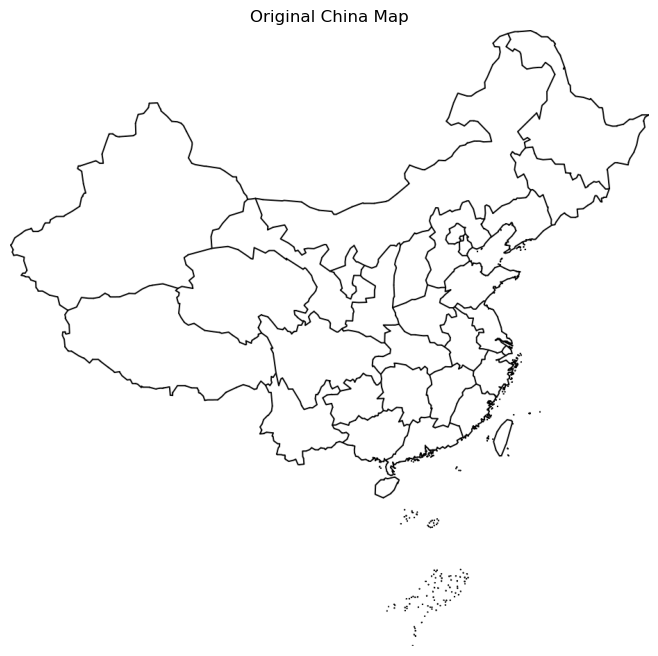

In [3]:
# Load the China map image
map_path = 'china_map.png' 

if os.path.exists(map_path):
    china_map = cv2.imread(map_path)
    china_map = cv2.cvtColor(china_map, cv2.COLOR_BGR2RGB)
else:
    print(f"Error: Image file not found at {map_path}")
    # Create a placeholder image for demonstration
    china_map = np.ones((400, 400, 3), dtype=np.uint8) * 255
    cv2.rectangle(china_map, (100, 100), (300, 300), (0, 0, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(china_map)
plt.title('Original China Map')
plt.axis('off')
plt.show()

## 3. Preprocess and Segment the Map

We'll use contour-based segmentation which works well for maps with clear region boundaries. This approach identifies and segments the different provinces of China.

Detected 31 regions in the map


C:\Users\OussamaLaaroussi\AppData\Local\Temp\ipykernel_5036\635027944.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('tab20', num_segments)


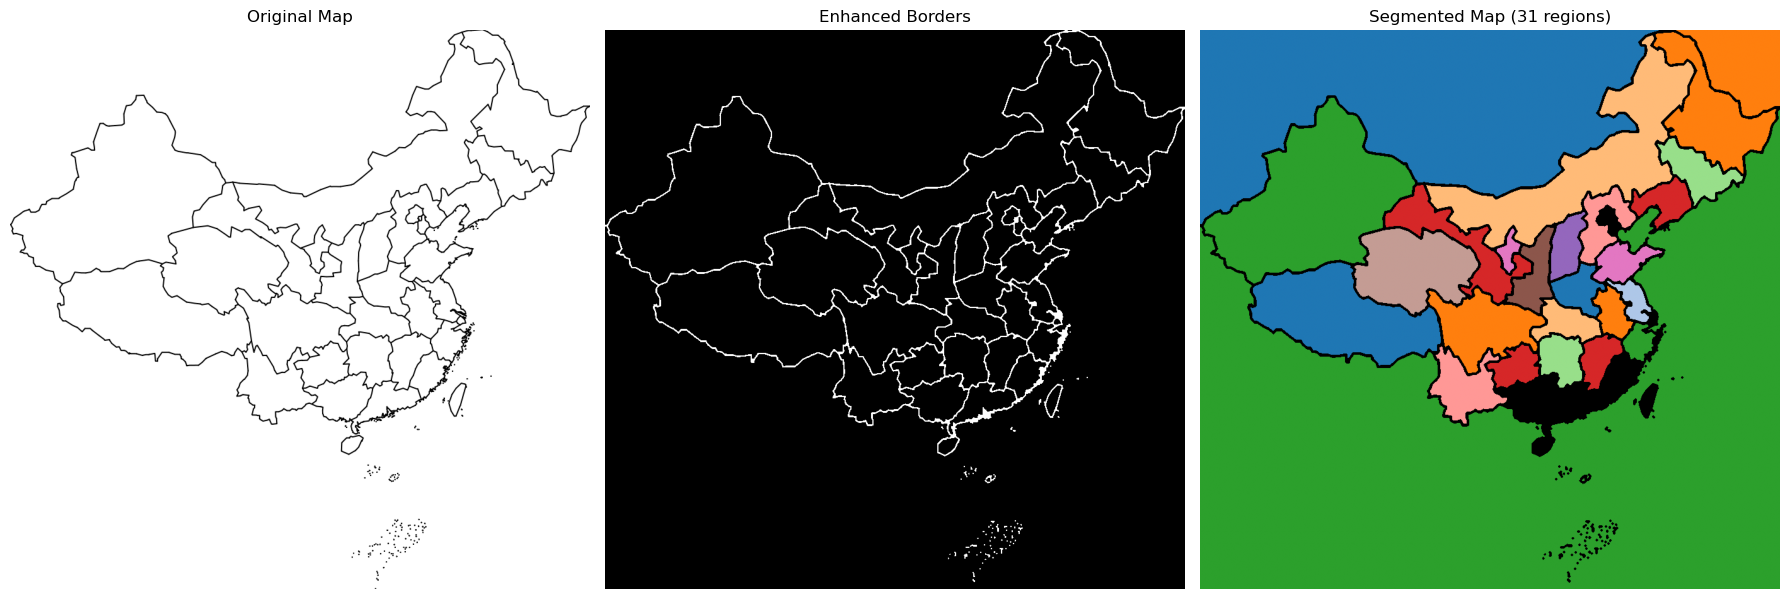

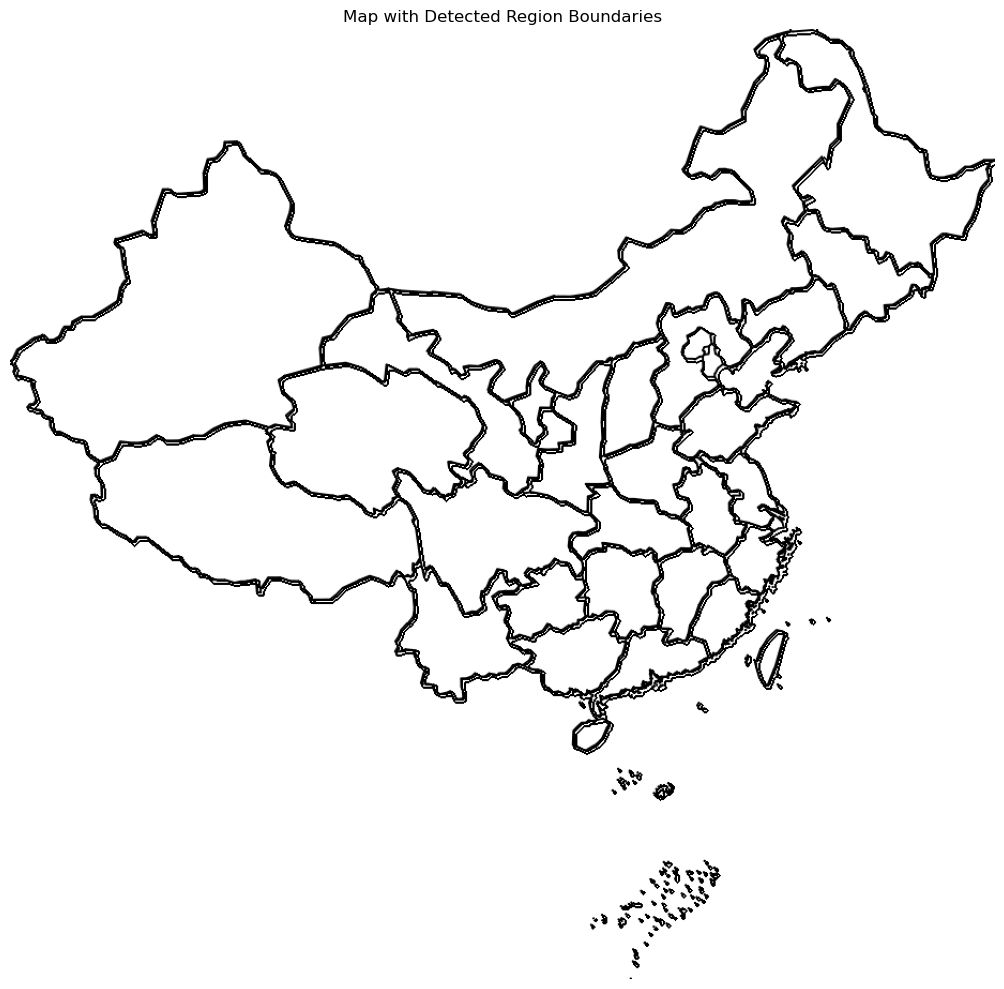

Number of segments (potential regions) found: 31


In [4]:
def preprocess_map_image(image):
    """
    Specialized preprocessing for map images to enhance borders between regions.
    """
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image.copy()
    
    # Apply bilateral filter to reduce noise while preserving edges
    blurred = cv2.bilateralFilter(gray, 9, 75, 75)
    
    # Apply threshold to convert to binary image
    # This works better for maps with clear black boundaries on white background
    _, binary = cv2.threshold(blurred, 220, 255, cv2.THRESH_BINARY_INV)
    
    # Dilate to strengthen and connect borders
    kernel = np.ones((2, 2), np.uint8)
    dilated = cv2.dilate(binary, kernel, iterations=1)
    
    # Close small gaps in borders
    closed = cv2.morphologyEx(dilated, cv2.MORPH_CLOSE, kernel, iterations=1)
    
    # Thin the borders for better region detection
    thinned = cv2.morphologyEx(closed, cv2.MORPH_ERODE, kernel, iterations=1)
    
    return thinned

def extract_regions_from_borders(border_image):
    """
    Extract enclosed regions from a border image using connected components
    """
    # Invert so borders are black (0) and regions are white (255)
    inverted = cv2.bitwise_not(border_image)
    
    # Use connected components to label regions
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(inverted, connectivity=8)
    
    # Filter very small regions that are likely noise
    min_region_size = 500  # Adjust based on your map
    cleaned_labels = np.zeros_like(labels)
    
    for i in range(1, num_labels):  # Skip background (label 0)
        if stats[i, cv2.CC_STAT_AREA] > min_region_size:
            cleaned_labels[labels == i] = i
    
    return cleaned_labels, border_image

def segment_china_map(image):
    """
    Segment the China map into provinces using specialized techniques
    """
    # Step 1: Preprocess the image to enhance borders
    preprocessed = preprocess_map_image(image)
    
    # Step 2: Extract regions from the enhanced borders
    segmented_image, borders = extract_regions_from_borders(preprocessed)
    
    # Step 3: Extract final boundaries for visualization
    boundaries = segmentation.find_boundaries(segmented_image)
    
    # Get the number of regions detected
    num_regions = len(np.unique(segmented_image)) - 1  # Subtract 1 for background
    print(f"Detected {num_regions} regions in the map")
    
    return segmented_image, boundaries, preprocessed

# Apply the segmentation approach
segmented_image, boundaries, preprocessed_image = segment_china_map(china_map)

# Display the results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(china_map)
axes[0].set_title('Original Map')
axes[0].axis('off')

axes[1].imshow(preprocessed_image, cmap='gray')
axes[1].set_title('Enhanced Borders')
axes[1].axis('off')

# Create a color visualization of the segmented image
from matplotlib.colors import ListedColormap
num_segments = len(np.unique(segmented_image)) - 1
colormap = plt.cm.get_cmap('tab20', num_segments)

# Create a random color for each label
segment_vis = np.zeros((*segmented_image.shape, 3))
for i in range(1, num_segments + 1):
    segment_vis[segmented_image == i] = colormap(i % 20)[:3]

# Overlay boundaries in black
segment_vis[boundaries] = [0, 0, 0]

axes[2].imshow(segment_vis)
axes[2].set_title(f'Segmented Map ({num_segments} regions)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Overlay segmentation on original map
overlay = china_map.copy().astype(float) / 255
# Draw region boundaries
overlay[boundaries] = [0, 0, 0]  # Black boundaries

plt.figure(figsize=(12, 10))
plt.imshow(overlay)
plt.title('Map with Detected Region Boundaries')
plt.axis('off')
plt.tight_layout()
plt.show()

# Print the number of segments found
num_segments = len(np.unique(segmented_image)) - 1  # Subtract 1 for background
print(f"Number of segments (potential regions) found: {num_segments}")

# If we still have issues with segmentation, try alternative approach
if num_segments < 10:  # We expect more regions for China's provinces
    print("Warning: Not enough regions detected. Trying alternative approach...")
    
    # Alternative segmentation approach for maps with less distinct borders
    def alternative_segmentation(image):
        # Convert to grayscale if needed
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image.copy()
        
        # Apply adaptive thresholding
        binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                       cv2.THRESH_BINARY_INV, 11, 2)
        
        # Apply Canny edge detection with low thresholds
        edges = cv2.Canny(gray, 20, 100)
        
        # Combine binary and edges
        combined = cv2.bitwise_or(binary, edges)
        
        # Dilate to strengthen lines
        kernel = np.ones((2, 2), np.uint8)
        dilated = cv2.dilate(combined, kernel, iterations=1)
        
        # Apply watershed algorithm for better segmentation
        # First get sure foreground regions
        dist_transform = cv2.distanceTransform(cv2.bitwise_not(dilated), cv2.DIST_L2, 3)
        _, sure_fg = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255, 0)
        sure_fg = sure_fg.astype(np.uint8)
        
        # Find unknown region
        sure_bg = cv2.dilate(dilated, kernel, iterations=3)
        unknown = cv2.subtract(sure_bg, sure_fg)
        
        # Marker labelling
        _, markers = cv2.connectedComponents(sure_fg)
        markers = markers + 1
        markers[unknown == 255] = 0
        
        # Apply watershed
        img_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
        cv2.watershed(img_rgb, markers)
        
        return markers, dilated
    
    # Apply alternative segmentation
    alt_segmented, alt_preprocessed = alternative_segmentation(china_map)
    alt_boundaries = segmentation.find_boundaries(alt_segmented)
    
    # Display alternative segmentation results
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(china_map)
    axes[0].set_title('Original Map')
    axes[0].axis('off')
    
    axes[1].imshow(alt_preprocessed, cmap='gray')
    axes[1].set_title('Alternative Preprocessing')
    axes[1].axis('off')
    
    alt_num_segments = len(np.unique(alt_segmented)) - 1  # Subtract 1 for background
    alt_colormap = plt.cm.get_cmap('tab20', alt_num_segments)
    
    # Create a random color for each label
    alt_segment_vis = np.zeros((*alt_segmented.shape, 3))
    for i in range(1, alt_num_segments + 1):
        alt_segment_vis[alt_segmented == i] = alt_colormap(i % 20)[:3]
    
    # Overlay boundaries
    alt_segment_vis[alt_boundaries] = [0, 0, 0]
    
    axes[2].imshow(alt_segment_vis)
    axes[2].set_title(f'Alternative Segmentation ({alt_num_segments} regions)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Use the better segmentation result
    if alt_num_segments > num_segments:
        print(f"Using alternative segmentation with {alt_num_segments} regions")
        segmented_image = alt_segmented
        boundaries = alt_boundaries
        num_segments = alt_num_segments
    else:
        print(f"Keeping original segmentation with {num_segments} regions")

## 4. Analyze and Refine Region Detection

Let's analyze the segmentation results and refine them if necessary.

Number of regions: 31
Regions sorted by area (largest first):
Region 7: Area = 378414.0, Centroid = (490.3, 654.9)
Region 1: Area = 145894.0, Centroid = (336.3, 112.0)
Region 6: Area = 50907.0, Centroid = (178.2, 272.2)
Region 5: Area = 38419.0, Centroid = (611.1, 209.4)
Region 20: Area = 28675.0, Centroid = (224.0, 454.6)
Region 17: Area = 18758.0, Centroid = (338.2, 378.7)
Region 4: Area = 16950.0, Centroid = (811.3, 132.4)
Region 3: Area = 14559.0, Centroid = (860.3, 56.2)
Region 24: Area = 12829.0, Centroid = (449.1, 471.9)
Region 10: Area = 10472.0, Centroid = (408.9, 338.4)


C:\Users\OussamaLaaroussi\AppData\Local\Temp\ipykernel_5036\356852571.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


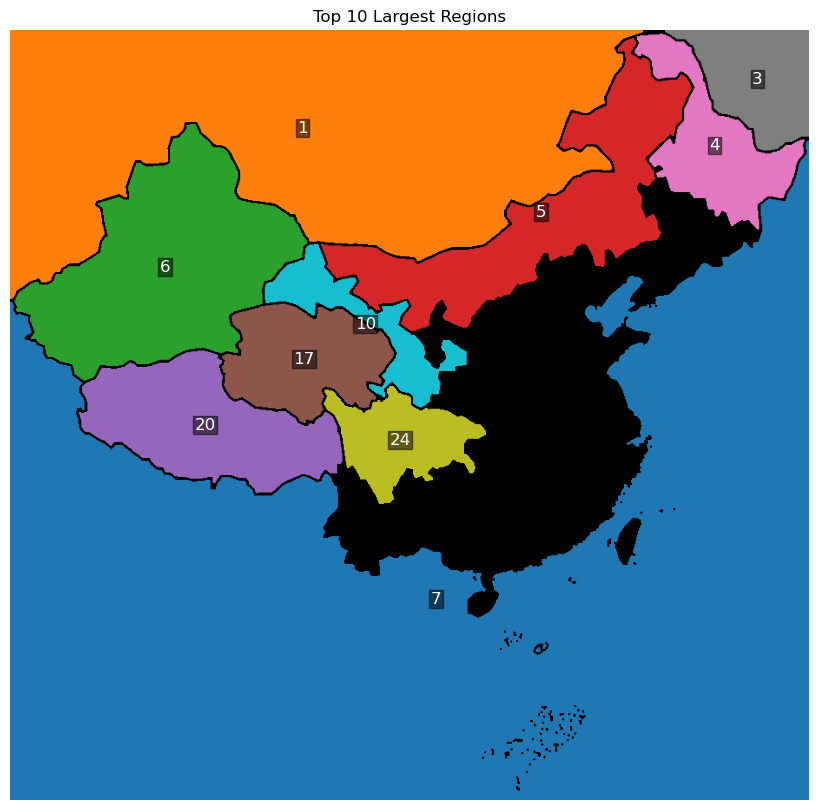

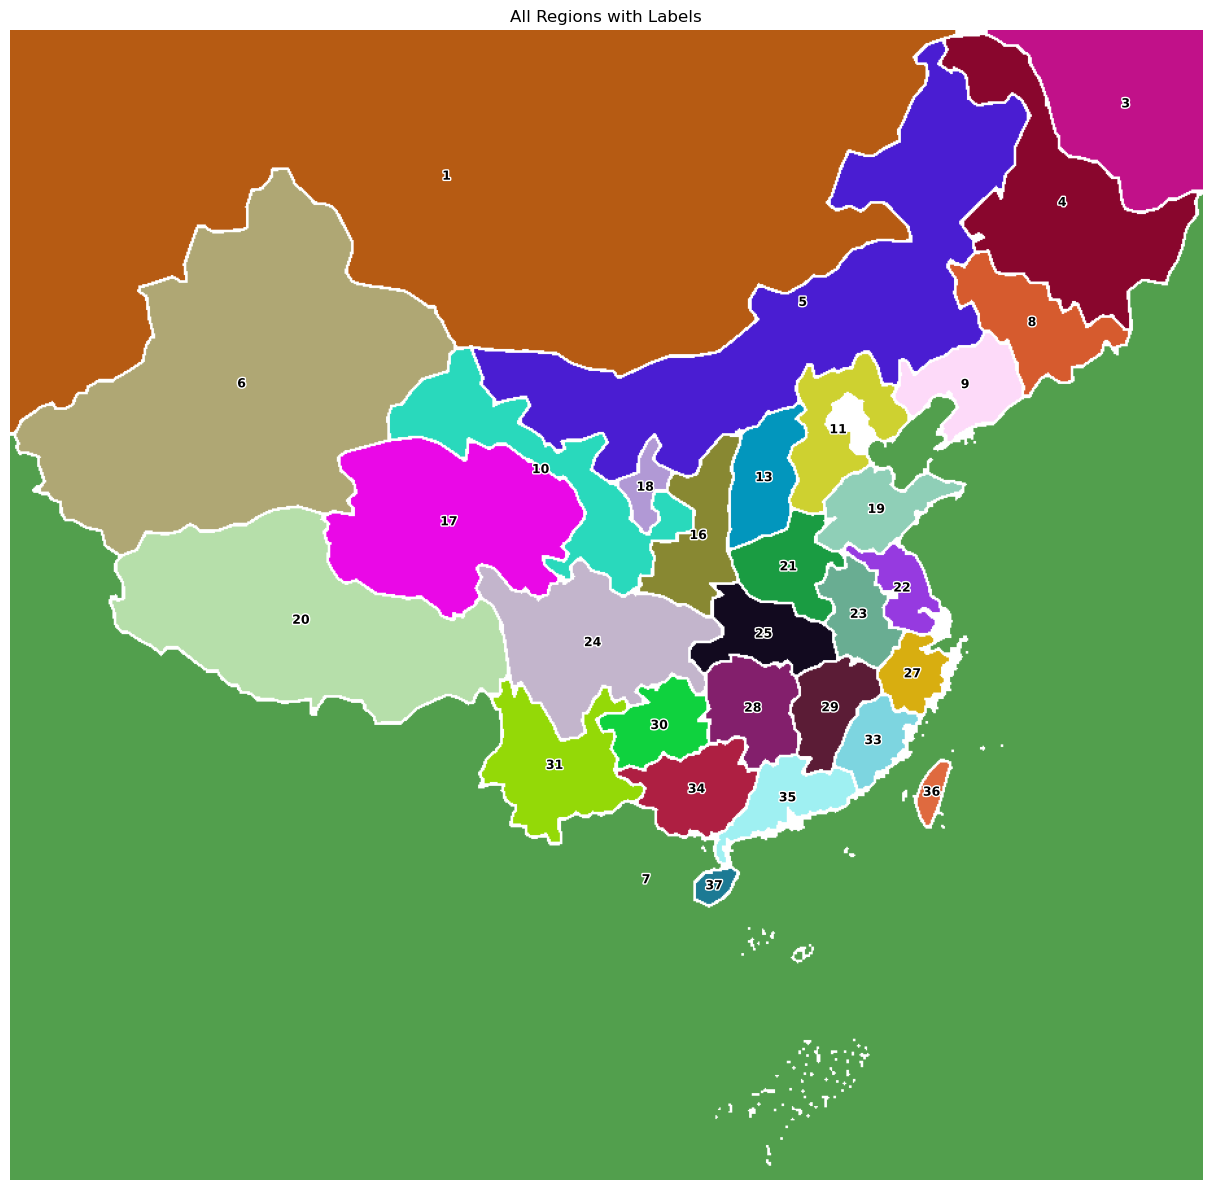

In [5]:
# Get region properties from the segmented image
region_props = measure.regionprops(segmented_image)

# Display information about the detected regions
print(f"Number of regions: {len(region_props)}")
print(f"Regions sorted by area (largest first):")
sorted_regions = sorted(region_props, key=lambda x: x.area, reverse=True)
for i, prop in enumerate(sorted_regions[:10]):  # Show top 10 regions by area
    print(f"Region {prop.label}: Area = {prop.area}, Centroid = ({prop.centroid[1]:.1f}, {prop.centroid[0]:.1f})")

# Visualize the top regions with distinct colors
plt.figure(figsize=(12, 10))
plt.imshow(np.zeros_like(segmented_image), cmap='gray')
plt.title('Top 10 Largest Regions')

cmap = plt.cm.get_cmap('tab10')
for i, prop in enumerate(sorted_regions[:10]):
    y, x = prop.centroid
    mask = segmented_image == prop.label
    color_mask = np.zeros((segmented_image.shape[0], segmented_image.shape[1], 4), dtype=np.float32)
    color = cmap(i % 10)
    color_mask[mask] = color
    plt.imshow(color_mask)
    plt.text(x, y, str(prop.label), color='white', fontsize=12, 
             ha='center', va='center', 
             bbox=dict(facecolor='black', alpha=0.5, pad=1))

plt.axis('off')
plt.show()

# Create a more detailed visualization of all regions
plt.figure(figsize=(14, 12))
# Create a random colored segmentation for visualization
random_colors = np.random.random((len(region_props) + 1, 3))
random_colors[0] = [1, 1, 1]  # Background is white

# Create an RGB representation of the segmented image
seg_rgb = np.zeros((*segmented_image.shape, 3))
for i, label in enumerate(np.unique(segmented_image)):
    seg_rgb[segmented_image == label] = random_colors[i]

# Draw labels at each region's centroid
for prop in region_props:
    y, x = prop.centroid
    plt.text(x, y, str(prop.label), color='black', fontsize=9, 
             ha='center', va='center', fontweight='bold',
             path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])

plt.imshow(seg_rgb)
plt.title('All Regions with Labels')
plt.axis('off')
plt.tight_layout()
plt.show()

# Optional: Function to manually merge small regions or fix incorrect segmentation
def merge_regions(segmented_image, source_label, target_label):
    """Merge a source region into a target region"""
    result = segmented_image.copy()
    result[result == source_label] = target_label
    return result

# Uncomment and modify as needed to merge specific regions
# segmented_image = merge_regions(segmented_image, source_label=5, target_label=2)
# region_props = measure.regionprops(segmented_image)
# print(f"After merging: {len(region_props)} regions remain")

## 5. Load Province Values from CSV

Now let's load the values for each province from a CSV file.

In [6]:
# Load province values
csv_path = 'china_map_values.csv'  # Update this path if needed

try:
    province_values_df = pd.read_csv(csv_path)
    print("CSV data loaded successfully:")
    print(province_values_df.head())
except FileNotFoundError:
    print(f"Warning: CSV file not found at {csv_path}")
    # Create sample data for demonstration
    provinces = [
        "Beijing", "Tianjin", "Hebei", "Shanxi", "Inner Mongolia",
        "Liaoning", "Jilin", "Heilongjiang", "Shanghai", "Jiangsu",
        "Zhejiang", "Anhui", "Fujian", "Jiangxi", "Shandong",
        "Henan", "Hubei", "Hunan", "Guangdong", "Guangxi",
        "Hainan", "Chongqing", "Sichuan", "Guizhou", "Yunnan",
        "Tibet", "Shaanxi", "Gansu", "Qinghai", "Ningxia", "Xinjiang"
    ]
    # Use more realistic number of provinces (China has 34 provincial-level regions)
    num_provinces = min(31, num_segments)
    values = np.random.uniform(1.0, 1.3, num_provinces)
    provinces = provinces[:num_provinces]
    province_values_df = pd.DataFrame({'Provinces': provinces, 'Mb 2005': values})
    print("Using sample province values:")
    print(province_values_df.head())

CSV data loaded successfully:
  Provinces  Mb 2005
0     Hubei    1.263
1    Fujian    1.255
2   Guangxi    1.248
3   Shaanxi    1.239
4   Jiangsu    1.237


## 6. Map Regions to Provinces

We'll create a robust mapping between detected regions and provinces.

Province to Region Mapping:
Hubei: Region 7 (Area: 378414.0)
Fujian: Region 1 (Area: 145894.0)
Guangxi: Region 6 (Area: 50907.0)
Shaanxi: Region 5 (Area: 38419.0)
Jiangsu: Region 20 (Area: 28675.0)
Henan: Region 17 (Area: 18758.0)
Guangdong: Region 4 (Area: 16950.0)
Chongqing: Region 3 (Area: 14559.0)
Jiangxi: Region 24 (Area: 12829.0)
Hainan: Region 10 (Area: 10472.0)
Hunan: Region 31 (Area: 7689.0)
Zhejiang: Region 8 (Area: 6016.0)
Shanghai: Region 16 (Area: 5026.0)
Shandong: Region 11 (Area: 4986.0)
Liaoning: Region 34 (Area: 4610.0)
Anhui: Region 28 (Area: 4415.0)
Inner Mongolia: Region 25 (Area: 4202.0)
Sichuan: Region 9 (Area: 4138.0)
Jilin: Region 13 (Area: 4096.0)
Tianjin: Region 21 (Area: 3949.0)
Yunnan: Region 19 (Area: 3847.0)
Heilongjiang: Region 30 (Area: 3563.0)
Guizhou: Region 29 (Area: 3476.0)
Gansu: Region 35 (Area: 3216.0)
Hebei: Region 23 (Area: 3046.0)
Beijing: Region 33 (Area: 2334.0)
Shanxi: Region 22 (Area: 2148.0)
Xinjiang: Region 27 (Area: 2029.0)
Qinghai: Regi

C:\Users\OussamaLaaroussi\AppData\Local\Temp\ipykernel_5036\2993706992.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  distinct_cmap = plt.cm.get_cmap('tab20', num_provinces)


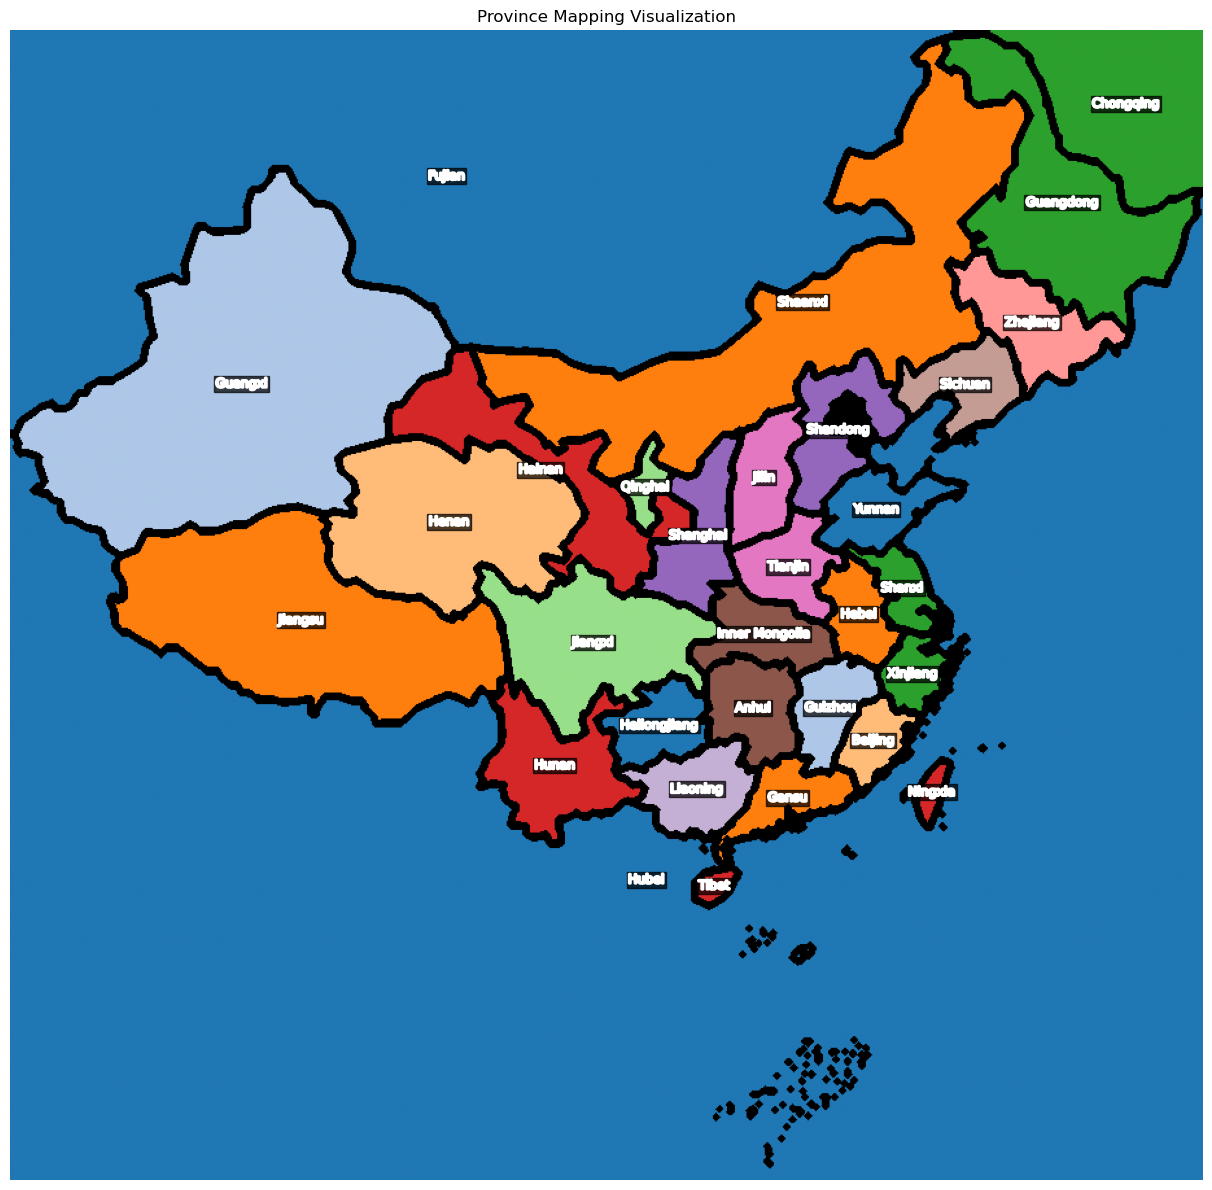

In [7]:
def improved_region_province_mapping(segmented_image, region_props, provinces_df):
    """
    Create a mapping between detected regions and provinces.
    This approach uses region size as the primary criterion.
    """
    # Get province names
    provinces = provinces_df['Provinces'].tolist()
    
    # Sort regions by area (largest first) 
    sorted_regions = sorted(region_props, key=lambda x: x.area, reverse=True)
    
    # Determine the number of provinces we can map
    num_provinces = min(len(provinces), len(sorted_regions))
    provinces = provinces[:num_provinces]  # Truncate if we have fewer regions than provinces
    main_regions = sorted_regions[:num_provinces]
    
    # Create the mapping: match largest provinces to largest regions
    province_to_region = {}
    for i, (province, region) in enumerate(zip(provinces, main_regions)):
        province_to_region[province] = region.label
    
    # Print the mapping for reference
    print("Province to Region Mapping:")
    for province, region_id in province_to_region.items():
        region_area = next((p.area for p in region_props if p.label == region_id), 0)
        print(f"{province}: Region {region_id} (Area: {region_area})")
    
    # Create a visualization of the mapping
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Use distinct colors for each province
    distinct_cmap = plt.cm.get_cmap('tab20', num_provinces)
    
    # Create an RGB representation with assigned provinces
    province_map = np.zeros((*segmented_image.shape, 3))
    
    # Assign colors to regions based on province mapping
    for i, (province, region_id) in enumerate(province_to_region.items()):
        color = distinct_cmap(i % 20)[:3]  # Get RGB from colormap
        province_map[segmented_image == region_id] = color
    
    # Extract boundaries for overlay
    boundaries_mask = np.zeros_like(segmented_image, dtype=bool)
    for label in np.unique(segmented_image):
        if label > 0:  # Skip background
            region_mask = segmented_image == label
            # Find the boundaries of this region
            boundary = segmentation.find_boundaries(region_mask, mode='inner')
            boundaries_mask = boundaries_mask | boundary
    
    # Dilate boundaries for better visibility
    boundaries_mask = morphology.binary_dilation(boundaries_mask, morphology.disk(1))
    province_map[boundaries_mask] = [0, 0, 0]  # Black boundaries
    
    ax.imshow(province_map)
    
    # Add province labels to the map
    for province, region_id in province_to_region.items():
        # Find the centroid of the region
        region = next((p for p in region_props if p.label == region_id), None)
        if region:
            y, x = region.centroid
            ax.text(x, y, province, color='white', fontsize=9, 
                   ha='center', va='center', 
                   bbox=dict(facecolor='black', alpha=0.7, pad=1),
                   path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])
    
    ax.set_title('Province Mapping Visualization')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    return province_to_region

# Apply the improved mapping
province_mapping = improved_region_province_mapping(segmented_image, region_props, province_values_df)

# Create a function for manual region-province adjustment
def manual_province_mapping(segmented_image, region_props, provinces_df, manual_mappings=None):
    """
    Create a manual mapping between provinces and regions.
    
    Parameters:
    -----------
    segmented_image : array
        The segmented image with region labels
    region_props : list
        List of region properties
    provinces_df : DataFrame
        DataFrame with province names and values
    manual_mappings : dict, optional
        Dictionary mapping province names to region labels
        
    Returns:
    --------
    dict
        Mapping from province names to region labels
    """
    if manual_mappings is None:
        # If no manual mappings are provided, return the default mapping
        return improved_region_province_mapping(segmented_image, region_props, provinces_df)
    
    # Get province names
    provinces = provinces_df['Provinces'].tolist()
    
    # Create a new mapping from the manual mappings
    province_to_region = {}
    for province in provinces:
        if province in manual_mappings:
            province_to_region[province] = manual_mappings[province]
    
    return province_to_region

# Uncomment and modify to create manual mappings
# Example of creating manual mappings:
# manual_mappings = {
#     'Beijing': 5,
#     'Shanghai': 12,
#     'Guangdong': 3,
#     # Add more as needed
# }
# province_mapping = manual_province_mapping(segmented_image, region_props, province_values_df, manual_mappings)

## 7. Create a Heatmap Visualization

Now we'll create a heatmap by assigning colors to each region based on the values from the CSV file.

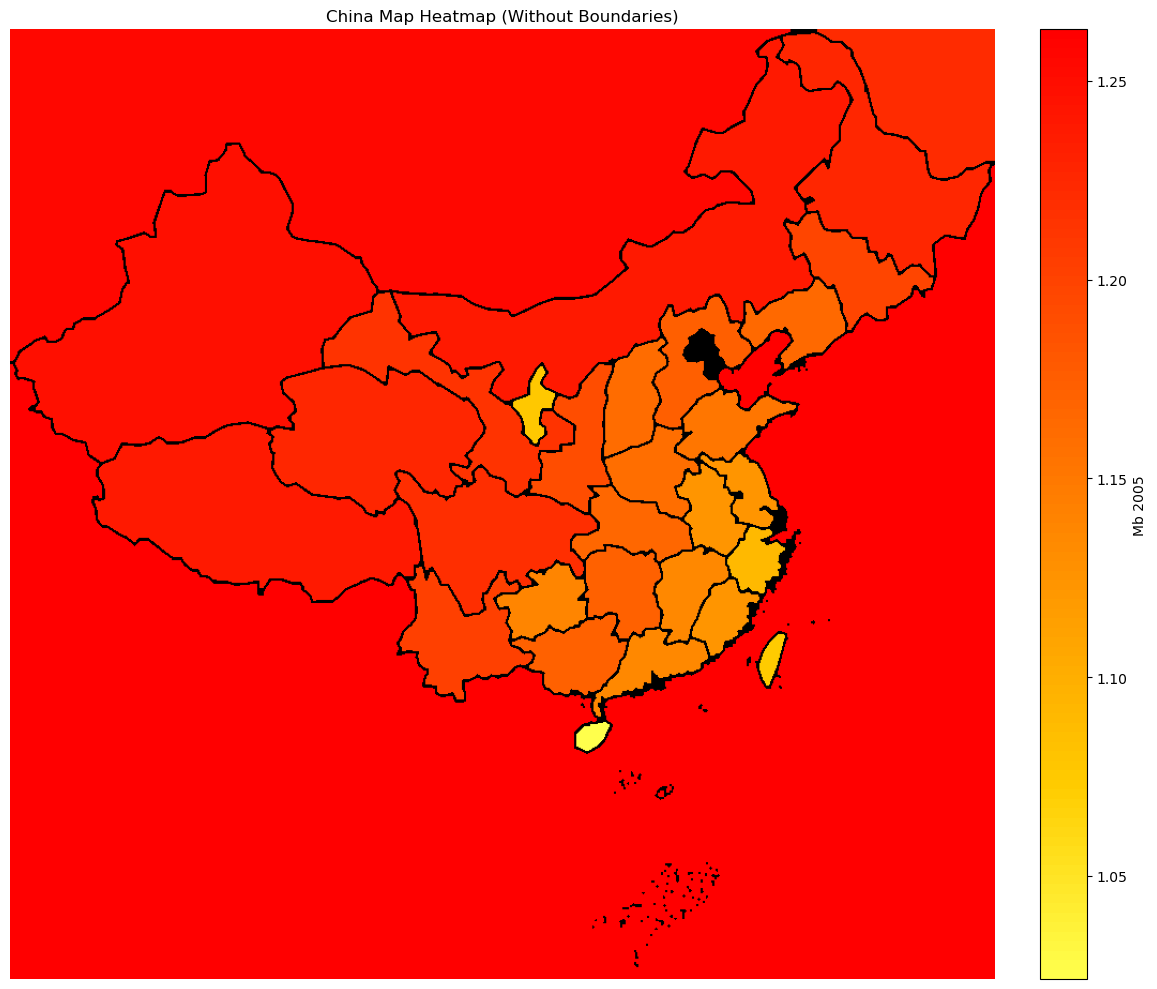

In [8]:
def create_heatmap(segmented_image, values_df, province_mapping):
    """Create a heatmap based on segmented regions and values."""
    # Create a normalized colormap from yellow to red
    colors = [(1, 1, 0.3), (1, 0.8, 0), (1, 0.6, 0), 
              (1, 0.4, 0), (1, 0.2, 0), (1, 0, 0)]
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=n_bins)
    
    # Get the province names and values
    value_column = 'Mb 2005'
    
    # Create a province to value mapping
    province_to_value = {}
    for _, row in values_df.iterrows():
        province_to_value[row['Provinces']] = row[value_column]
    
    # Normalize values for colormap
    values = np.array(list(province_to_value.values()))
    min_val, max_val = np.min(values), np.max(values)
    norm_values = (values - min_val) / (max_val - min_val)
    
    # Create province colors
    province_colors = {}
    for i, (province, value) in enumerate(province_to_value.items()):
        norm_value = (value - min_val) / (max_val - min_val)
        rgba_color = cmap(norm_value)
        province_colors[province] = rgba_color[:3]
    
    # Create the heatmap
    heatmap = np.zeros((segmented_image.shape[0], segmented_image.shape[1], 3), dtype=np.float32)
    
    # Assign colors to each region based on province mapping
    for province, region_id in province_mapping.items():
        if province in province_colors:
            mask = (segmented_image == region_id)
            for i in range(3):
                heatmap[:, :, i][mask] = province_colors[province][i]
    
    return heatmap, cmap, min_val, max_val

# Create the heatmap
heatmap, cmap, min_val, max_val = create_heatmap(segmented_image, province_values_df, province_mapping)

# Display the heatmap
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(heatmap)
ax.set_title('China Map Heatmap (Without Boundaries)')
ax.axis('off')

# Add a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(min_val, max_val))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
value_column = 'Mb 2005'
cbar.set_label(value_column)

plt.tight_layout()
plt.show()

## 8. Enhance Visualization with Boundaries and Labels

Let's enhance the heatmap by adding clear boundaries and province labels.

C:\Users\OussamaLaaroussi\AppData\Local\Temp\ipykernel_5036\677906780.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


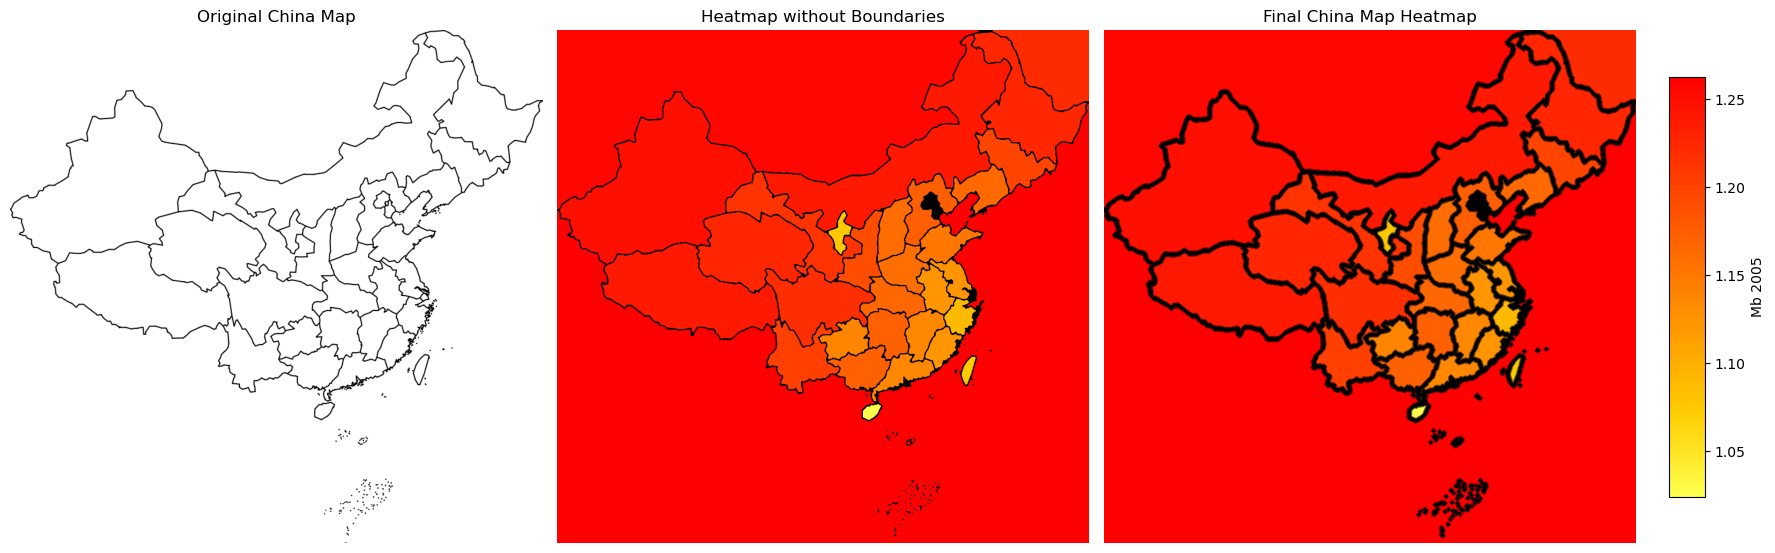

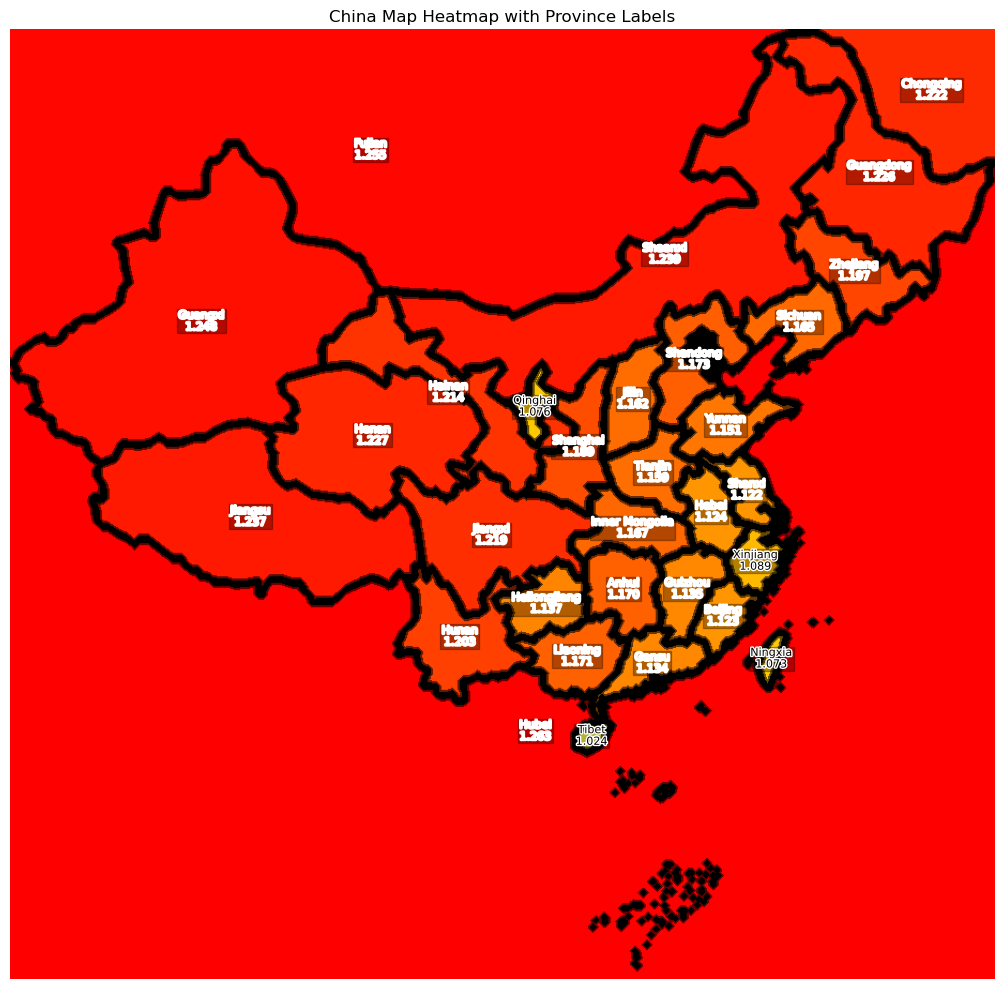

In [11]:
def extract_enhanced_boundaries(segmented_image):
    """Extract enhanced boundaries from the segmented image"""
    # Create a mask for all boundaries
    all_boundaries = np.zeros_like(segmented_image, dtype=bool)
    
    # For each region, find its boundary and add to the mask
    for label in np.unique(segmented_image):
        if label > 0:  # Skip background
            region_mask = segmented_image == label
            region_boundary = segmentation.find_boundaries(region_mask, mode='outer')
            all_boundaries = all_boundaries | region_boundary
    
    # Apply multiple dilations for thicker, more prominent boundaries
    dilated_boundaries = morphology.binary_dilation(all_boundaries, morphology.disk(1))
    # Second pass of dilation
    dilated_boundaries = morphology.binary_dilation(dilated_boundaries, morphology.disk(1))
    
    return dilated_boundaries

def overlay_enhanced_boundaries(heatmap, boundaries, shadow_strength=0.3):
    """Overlay enhanced boundaries on the heatmap"""
    result = heatmap.copy()
    
    # Make boundaries pure black
    for i in range(3):
        channel = result[:, :, i]
        channel[boundaries] = 0  # Pure black
        result[:, :, i] = channel
    
    # Create a shadow effect around boundaries for better visibility
    shadow = morphology.binary_dilation(boundaries, morphology.disk(2))
    shadow = shadow & ~boundaries  # Only keep the outer ring
    
    # Apply shadow effect
    for i in range(3):
        channel = result[:, :, i]
        channel[shadow] = channel[shadow] * shadow_strength  # Darken by specified amount
        result[:, :, i] = channel
    
    return result

def add_province_labels(image, segmented_image, province_mapping, province_values_df):
    """Add province labels to the image"""
    result = image.copy()
    
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.imshow(result)
    
    # Get region properties
    props = measure.regionprops(segmented_image)
    
    # Create a reverse mapping from region ID to province name
    region_to_province = {region_id: province for province, region_id in province_mapping.items()}
    
    # Add labels to provinces
    for prop in props:
        region_id = prop.label
        if region_id in region_to_province:
            y, x = prop.centroid
            province = region_to_province[region_id]
            
            # Get value for this province
            value_data = province_values_df[province_values_df['Provinces'] == province]
            if len(value_data) > 0:
                province_value = value_data['Mb 2005'].values[0]
                
                # Determine text color based on background brightness
                centroid_y, centroid_x = int(y), int(x)
                if 0 <= centroid_y < result.shape[0] and 0 <= centroid_x < result.shape[1]:
                    pixel = result[centroid_y, centroid_x]
                    brightness = 0.299 * pixel[0] + 0.587 * pixel[1] + 0.114 * pixel[2]
                    text_color = 'white' if brightness < 0.7 else 'black'
                else:
                    text_color = 'white'  # Default color
                
                # Add label with province name and value, with a white outline for better visibility
                ax.text(x, y, f"{province}\n{province_value:.3f}", color=text_color, fontsize=8, 
                       ha='center', va='center', 
                       bbox=dict(facecolor='black', alpha=0.3, pad=1),
                       path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])
    
    ax.set_title('China Map Heatmap with Province Labels')
    ax.axis('off')
    plt.tight_layout()
    
    return fig, ax

# Extract enhanced boundaries
enhanced_boundaries = extract_enhanced_boundaries(segmented_image)

# Overlay enhanced boundaries on heatmap
final_map = overlay_enhanced_boundaries(heatmap, enhanced_boundaries, shadow_strength=0.4)

# Display the result with a three-panel figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(china_map)
axes[0].set_title('Original China Map')
axes[0].axis('off')

axes[1].imshow(heatmap)
axes[1].set_title('Heatmap without Boundaries')
axes[1].axis('off')

axes[2].imshow(final_map)
axes[2].set_title('Final China Map Heatmap')
axes[2].axis('off')

# Add a colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(min_val, max_val))
sm.set_array([])
cbar = plt.colorbar(sm, cax=cbar_ax)
value_column = 'Mb 2005'
cbar.set_label(value_column)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

# Create a version with province labels
labeled_fig, labeled_ax = add_province_labels(final_map, segmented_image, province_mapping, province_values_df)
plt.show()

In [15]:
# Save the final heatmap visualization
output_path = 'china_map_heatmap.png'

# Create a new figure and axis for saving the unlabeled heatmap
save_fig, save_ax = plt.subplots(figsize=(12, 10))
save_ax.imshow(final_map)
save_ax.set_title('China Map Heatmap')
save_ax.axis('off')

# Add colorbar with proper positioning, explicitly specifying the axes
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(min_val, max_val))
sm.set_array([])
cbar = plt.colorbar(sm, ax=save_ax, fraction=0.046, pad=0.04)
cbar.set_label('Mb 2005')

# Save the figure with high resolution
plt.tight_layout()
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.close(save_fig)  # Close the figure to free memory

print(f"Final heatmap saved to {output_path}")

# For the labeled version, we can use the labeled_fig directly
labeled_output_path = 'china_map_heatmap_labeled.png'

# Make sure the figure exists before saving
if 'labeled_fig' in locals() and labeled_fig is not None:
    # Adjust colorbar if needed
    labeled_fig.tight_layout()
    labeled_fig.savefig(labeled_output_path, dpi=300, bbox_inches='tight')
    plt.close(labeled_fig)  # Properly close the figure
    print(f"Labeled heatmap saved to {labeled_output_path}")
else:
    print("Error: Labeled figure was not created properly. Cannot save labeled heatmap.")

Final heatmap saved to china_map_heatmap.png
Labeled heatmap saved to china_map_heatmap_labeled.png
Labeled heatmap saved to china_map_heatmap_labeled.png


## 10. Advanced Customization (Optional)

Here we provide options for further customizing the visualization.

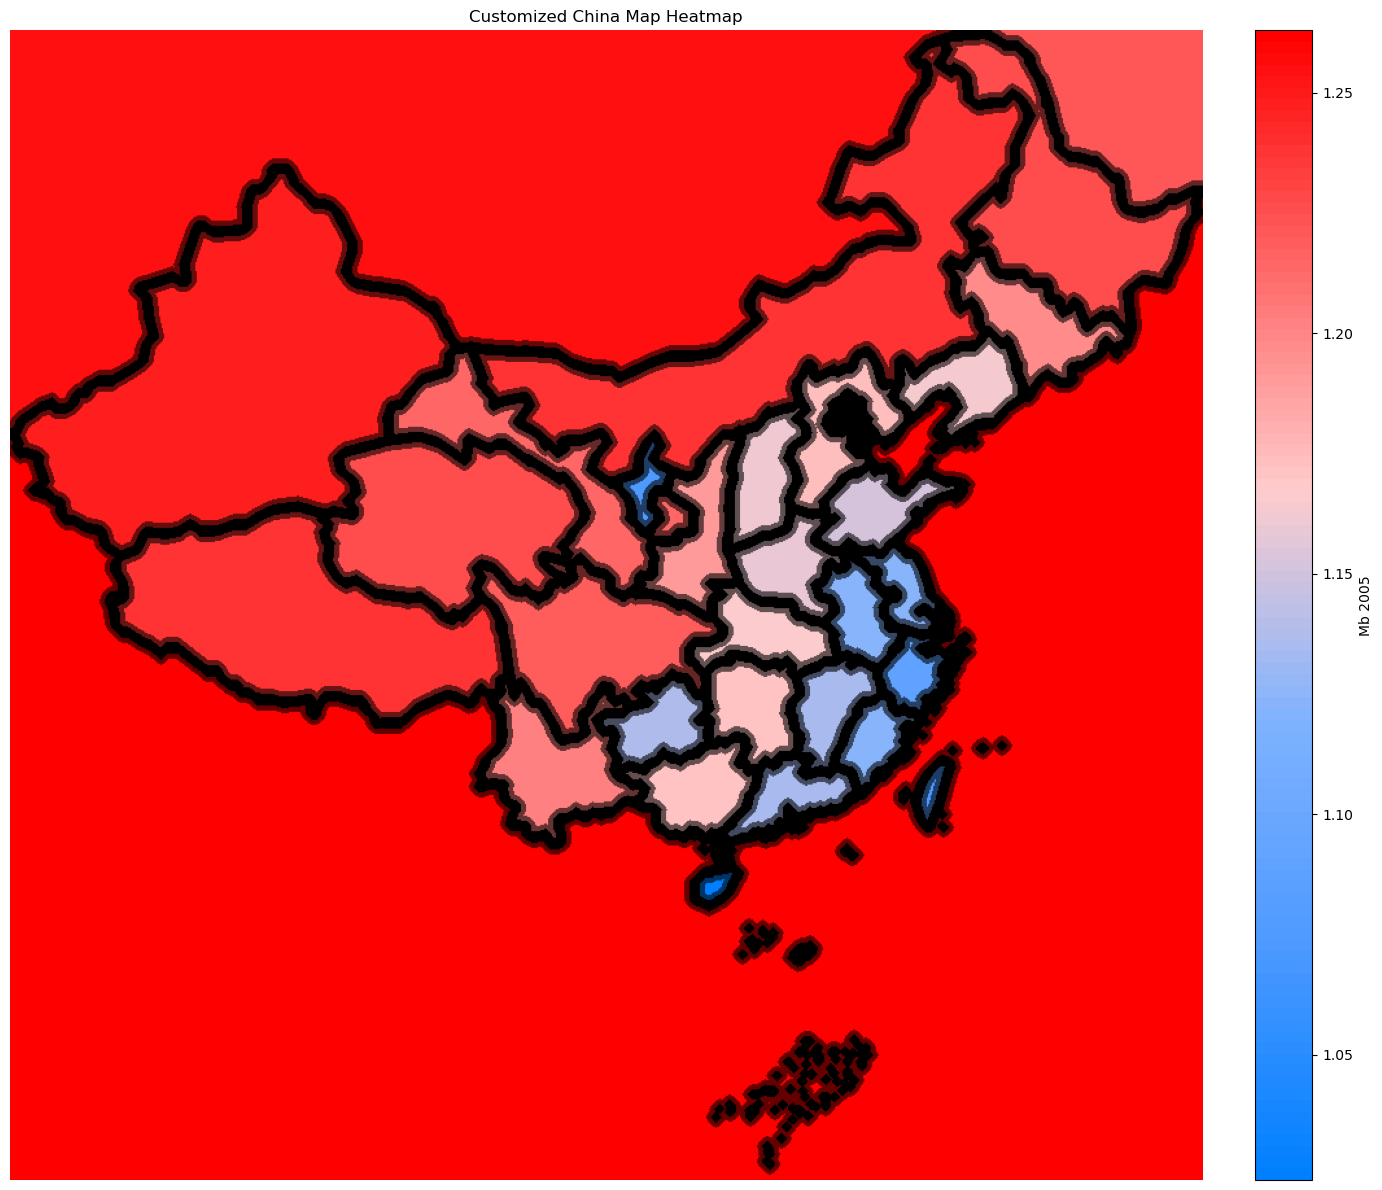

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from skimage import segmentation, morphology

def create_enhanced_heatmap(segmented_image, province_mapping, province_values_df, 
                            color_scheme='yellow_red', border_width=2, 
                            shadow_effect=True, shadow_intensity=0.4):
    """
    Create a highly customized heatmap with various enhancement options.
    """
    color_schemes = {
        'yellow_red': [(1, 1, 0.3), (1, 0.8, 0), (1, 0.6, 0), (1, 0.4, 0), (1, 0.2, 0), (1, 0, 0)],
        'blue_red': [(0, 0.5, 1), (0.3, 0.6, 1), (0.5, 0.7, 1), (1, 0.8, 0.8), (1, 0.4, 0.4), (1, 0, 0)],
        'viridis': None,
        'plasma': None
    }

    if color_scheme not in color_schemes:
        raise ValueError(f"Invalid color scheme '{color_scheme}'. Choose from {list(color_schemes.keys())}")

    cmap = LinearSegmentedColormap.from_list('custom_cmap', color_schemes[color_scheme], N=100) \
        if color_schemes[color_scheme] is not None else plt.cm.get_cmap(color_scheme)

    value_column = 'Mb 2005'
    province_to_value = dict(zip(province_values_df['Provinces'], province_values_df[value_column]))

    values = np.array(list(province_to_value.values()), dtype=np.float32)
    min_val, max_val = np.min(values), np.max(values)

    province_colors = {
        province: cmap((value - min_val) / (max_val - min_val))[:3]
        for province, value in province_to_value.items()
    }

    heatmap = np.zeros((*segmented_image.shape, 3), dtype=np.float32)
    for province, region_id in province_mapping.items():
        if province in province_colors:
            mask = (segmented_image == region_id)
            for i in range(3):
                heatmap[:, :, i][mask] = province_colors[province][i]

    boundaries = np.zeros_like(segmented_image, dtype=bool)
    for label in np.unique(segmented_image):
        if label == 0:
            continue
        region_mask = (segmented_image == label)
        boundaries |= segmentation.find_boundaries(region_mask, mode='outer')

    for _ in range(border_width):
        boundaries = morphology.binary_dilation(boundaries, morphology.disk(1))

    if shadow_effect:
        shadow = morphology.binary_dilation(boundaries, morphology.disk(border_width + 1)) & ~boundaries
        for i in range(3):
            heatmap[:, :, i][shadow] *= (1 - shadow_intensity)

    for i in range(3):
        heatmap[:, :, i][boundaries] = 0

    return heatmap, cmap, min_val, max_val




# Generate the heatmap
enhanced_heatmap, enhanced_cmap, min_val, max_val = create_enhanced_heatmap(
    segmented_image, province_mapping, province_values_df,
    color_scheme='blue_red',
    border_width=3,
    shadow_effect=True,
    shadow_intensity=0.6
)

# Plot and show the heatmap with colorbar
fig, ax = plt.subplots(figsize=(14, 12))
img = ax.imshow(enhanced_heatmap)
ax.set_title('Customized China Map Heatmap')
ax.axis('off')

# Add colorbar using ScalarMappable
sm = plt.cm.ScalarMappable(cmap=enhanced_cmap, norm=plt.Normalize(min_val, max_val))
sm.set_array([])  # Dummy array required for ScalarMappable
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Mb 2005')

plt.tight_layout()
plt.savefig('china_map_heatmap_custom.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


## 11. Conclusion

In this notebook, we have successfully:
1. Loaded a China map image
2. Applied contour-based segmentation to identify regions
3. Analyzed and refined the segmented regions
4. Loaded values for each province from a CSV file
5. Mapped provinces to detected regions
6. Created a heatmap by coloring each region according to its associated value
7. Enhanced visualization with clear boundaries and province labels
8. Saved the final result
9. Provided options for advanced customization

This contour-based approach provides better region detection and clearer boundaries, resulting in a more accurate heatmap visualization of China's provinces.